In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import root_mean_squared_error, r2_score
import shap

%matplotlib inline

/home/utn/kocy61ry/Documents/ML Project/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df_2020 = pd.read_csv('data/delta_table_2020_3x3.csv')
df_2021 = pd.read_csv('data/delta_table_2021_3x3.csv')

df_2021 = df_2021[df_2021['delta_years'] != 5]

In [3]:
df_2020 = df_2020.drop(columns=['year', "system:index", "image_count", ".geo", "geometry", "x", "y"])
df_2020 = df_2020.fillna(df_2020.mean())

df_2021 = df_2021.drop(columns=['year', "system:index", "image_count", ".geo", "geometry", "x", "y"])
df_2021 = df_2021.fillna(df_2021.mean())

In [4]:
df_2020['vegetation'] = df_2020[['tree_cover', 'cropland', 'grassland']].sum(axis=1)
df_2021['vegetation'] = df_2021[['tree_cover', 'cropland', 'grassland']].sum(axis=1)

target_labels = [
    'built_up',
    'vegetation',
    'water'
]

remaining_target = [
    'bare_sparse_vegetation',
    'tree_cover',
    'grassland',
    'cropland'
]


In [5]:
# --- Feature Engineering for df_2020 ---
# Vegetation Indices
df_2020['NDVI'] = (df_2020['B8'] - df_2020['B4']) / (df_2020['B8'] + df_2020['B4'] + 1e-8)
# df_2020['EVI'] = 2.5 * ((df_2020['B8'] - df_2020['B4']) / (df_2020['B8'] + 6 * df_2020['B4'] - 7.5 * df_2020['B2'] + 1 + 1e-8))
df_2020['EVI2'] = 2.5 * ((df_2020['B8'] - df_2020['B4']) / (df_2020['B8'] + 2.4 * df_2020['B4'] + 1 + 1e-8))
df_2020['SAVI'] = ((df_2020['B8'] - df_2020['B4']) * 1.5) / (df_2020['B8'] + df_2020['B4'] + 0.5 + 1e-8)
# df_2020['NDRE'] = (df_2020['B8'] - df_2020['B5']) / (df_2020['B8'] + df_2020['B5'] + 1e-8)
# df_2020['GNDVI'] = (df_2020['B8'] - df_2020['B3']) / (df_2020['B8'] + df_2020['B3'] + 1e-8)

# Urban & Built-up Indices
df_2020['NDBI'] = (df_2020['B11'] - df_2020['B8']) / (df_2020['B11'] + df_2020['B8'] + 1e-8)

# Water & Moisture Indices
df_2020['NDWI'] = (df_2020['B3'] - df_2020['B8']) / (df_2020['B3'] + df_2020['B8'] + 1e-8)
df_2020['MNDWI'] = (df_2020['B3'] - df_2020['B11']) / (df_2020['B3'] + df_2020['B11'] + 1e-8)


# --- Feature Engineering for df_2021 ---
# Vegetation Indices
df_2021['NDVI'] = (df_2021['B8'] - df_2021['B4']) / (df_2021['B8'] + df_2021['B4'] + 1e-8)
# df_2021['EVI'] = 2.5 * ((df_2021['B8'] - df_2021['B4']) / (df_2021['B8'] + 6 * df_2021['B4'] - 7.5 * df_2021['B2'] + 1 + 1e-8))
df_2021['EVI2'] = 2.5 * ((df_2021['B8'] - df_2021['B4']) / (df_2021['B8'] + 2.4 * df_2021['B4'] + 1 + 1e-8))
df_2021['SAVI'] = ((df_2021['B8'] - df_2021['B4']) * 1.5) / (df_2021['B8'] + df_2021['B4'] + 0.5 + 1e-8)
# df_2021['NDRE'] = (df_2021['B8'] - df_2021['B5']) / (df_2021['B8'] + df_2021['B5'] + 1e-8)
# df_2021['GNDVI'] = (df_2021['B8'] - df_2021['B3']) / (df_2021['B8'] + df_2021['B3'] + 1e-8)

# Urban & Built-up Indices
df_2021['NDBI'] = (df_2021['B11'] - df_2021['B8']) / (df_2021['B11'] + df_2021['B8'] + 1e-8)

# Water & Moisture Indices
df_2021['NDWI'] = (df_2021['B3'] - df_2021['B8']) / (df_2021['B3'] + df_2021['B8'] + 1e-8)
df_2021['MNDWI'] = (df_2021['B3'] - df_2021['B11']) / (df_2021['B3'] + df_2021['B11'] + 1e-8)

In [6]:
X_train = df_2020.drop(columns=target_labels + remaining_target)
X_train = X_train.drop(columns=['B4', 'B7', 'B8', 'NDBI'])
y_train = df_2020[target_labels]

X_test = df_2021.drop(columns=target_labels + remaining_target)
X_test = X_test.drop(columns=['B4', 'B7', 'B8', 'NDBI'])
y_test = df_2021[target_labels]

In [7]:
X_train.columns, y_train.columns

(Index(['delta_years', 'B11', 'B12', 'B2', 'B3', 'B5', 'B6', 'B11_m1_m1',
        'B12_m1_m1', 'B2_m1_m1', 'B3_m1_m1', 'B4_m1_m1', 'B5_m1_m1', 'B6_m1_m1',
        'B7_m1_m1', 'B8_m1_m1', 'B11_p0_m1', 'B12_p0_m1', 'B2_p0_m1',
        'B3_p0_m1', 'B4_p0_m1', 'B5_p0_m1', 'B6_p0_m1', 'B7_p0_m1', 'B8_p0_m1',
        'B11_p1_m1', 'B12_p1_m1', 'B2_p1_m1', 'B3_p1_m1', 'B4_p1_m1',
        'B5_p1_m1', 'B6_p1_m1', 'B7_p1_m1', 'B8_p1_m1', 'B11_m1_p0',
        'B12_m1_p0', 'B2_m1_p0', 'B3_m1_p0', 'B4_m1_p0', 'B5_m1_p0', 'B6_m1_p0',
        'B7_m1_p0', 'B8_m1_p0', 'B11_p1_p0', 'B12_p1_p0', 'B2_p1_p0',
        'B3_p1_p0', 'B4_p1_p0', 'B5_p1_p0', 'B6_p1_p0', 'B7_p1_p0', 'B8_p1_p0',
        'B11_m1_p1', 'B12_m1_p1', 'B2_m1_p1', 'B3_m1_p1', 'B4_m1_p1',
        'B5_m1_p1', 'B6_m1_p1', 'B7_m1_p1', 'B8_m1_p1', 'B11_p0_p1',
        'B12_p0_p1', 'B2_p0_p1', 'B3_p0_p1', 'B4_p0_p1', 'B5_p0_p1', 'B6_p0_p1',
        'B7_p0_p1', 'B8_p0_p1', 'B11_p1_p1', 'B12_p1_p1', 'B2_p1_p1',
        'B3_p1_p1', 'B4_p1_p1', 'B5

In [8]:
import pickle

with open('models/XGBoost_delta.pkl', 'rb') as f:
    loaded_models = pickle.load(f)

best_model = loaded_models

y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

/home/utn/kocy61ry/Documents/ML Project/.venv/lib/python3.10/site-packages/xgboost/core.py:751: UserWarning: [23:36:33] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)
/home/utn/kocy61ry/Documents/ML Project/.venv/lib/python3.10/site-packages/xgboost/core.py:751: UserWarning: [23:36:33] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data str

In [11]:
X_test

,delta_years,B11,B12,B2,B3,B5,B6,B11_m1_m1,B12_m1_m1,B2_m1_m1,...,B4_p1_p1,B5_p1_p1,B6_p1_p1,B7_p1_p1,B8_p1_p1,NDVI,EVI2,SAVI,NDWI,MNDWI
0,2,2347.0,1739.5,1206.5,1334.0,1631.5,2457.0,1878.5,1144.5,347.5,...,1104.5,1514.0,2737.5,3147.0,3264.0,0.305789,0.514384,0.458628,-0.335078,-0.275197
1,2,2336.0,1842.0,1451.0,1719.5,2091.5,2630.0,2226.0,1518.0,908.0,...,1327.5,1582.5,2270.0,2606.0,2561.0,0.194604,0.311068,0.291874,-0.222034,-0.152016
2,2,2210.0,1874.0,1232.5,1417.0,1703.5,1808.5,2205.5,1763.0,1353.0,...,1097.5,1178.5,1985.5,2192.5,2392.5,0.083396,0.126979,0.125075,-0.117958,-0.218638
3,2,2078.5,1895.5,1091.0,1142.5,1187.0,1290.5,2074.5,1805.5,1194.0,...,1105.5,1332.0,2047.0,2402.0,2349.5,0.083584,0.127268,0.125351,-0.083801,-0.290593
4,2,2173.0,1900.0,1175.5,1294.0,1606.0,1679.5,2017.5,1835.0,1180.5,...,1534.0,1963.5,2489.5,2681.5,2698.5,0.065549,0.099048,0.098306,-0.092089,-0.253533
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2744173,4,2170.0,1300.0,470.0,917.0,1475.0,2244.0,1501.0,909.0,275.0,...,1016.0,1604.0,2873.0,3233.0,2874.0,0.515616,0.962443,0.773319,-0.502036,-0.405896
2744174,4,1901.0,1244.0,432.0,836.0,1281.0,2249.0,1478.0,876.0,264.0,...,839.0,1194.0,2590.0,2830.0,2921.0,0.587629,1.139739,0.881314,-0.526480,-0.389112
2744175,4,1483.0,845.0,389.0,530.0,861.0,1915.0,1492.0,737.0,232.0,...,1010.0,1279.0,2115.0,2298.0,2268.0,0.563826,1.079573,0.845592,-0.618431,-0.473423
2744176,4,1301.0,807.0,389.0,409.0,799.0,1559.0,1339.0,753.0,200.0,...,1081.0,1505.0,2195.0,2336.0,2249.0,0.527829,0.991427,0.791560,-0.602140,-0.521637


In [12]:
X_test['delta_years'].unique()

array([2, 3, 1, 0, 4])

In [9]:
train_rmse = root_mean_squared_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

test_rmse = root_mean_squared_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"Train R2: {train_r2:.4f} | Test R2: {test_r2:.4f}")
print(f"Train RMSE: {train_rmse:.4f} | Test RMSE: {test_rmse:.4f}\n")

Train R2: 0.8979 | Test R2: 0.8757
Train RMSE: 0.1107 | Test RMSE: 0.1252



In [10]:
loaded_models

,estimator,"XGBRegressor(...ree=None, ...)"
,n_jobs,-1
,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.6983814307724542
,device,'cuda'
,early_stopping_rounds,None


In [13]:
delta_values = [0, 1, 2, 3, 4]
results = []


for delta in sorted(delta_values):
    train_mask = df_2020['delta_years'] == delta
    test_mask = df_2021['delta_years'] == delta
    

    X_tr_delta = X_train[train_mask]
    y_tr_delta = y_train[train_mask]
    y_tr_pred = best_model.predict(X_tr_delta)
        
    tr_rmse = root_mean_squared_error(y_tr_delta, y_tr_pred)
    tr_r2 = r2_score(y_tr_delta, y_tr_pred)


    X_te_delta = X_test[test_mask]
    y_te_delta = y_test[test_mask]
    y_te_pred = best_model.predict(X_te_delta)
        
    te_rmse = root_mean_squared_error(y_te_delta, y_te_pred)
    te_r2 = r2_score(y_te_delta, y_te_pred)


    print(f"--- Delta Year: {delta} ---")
    print(f"Train R2: {tr_r2:.4f} | Test R2: {te_r2:.4f}")
    print(f"Train RMSE: {tr_rmse:.4f} | Test RMSE: {te_rmse:.4f}\n")
    
    results.append({
        'delta': delta,
        'train_r2': tr_r2,
        'test_r2': te_r2,
        'train_rmse': tr_rmse,
        'test_rmse': te_rmse
    })

res_df = pd.DataFrame(results)

/home/utn/kocy61ry/Documents/ML Project/.venv/lib/python3.10/site-packages/xgboost/core.py:751: UserWarning: [23:43:13] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)
/home/utn/kocy61ry/Documents/ML Project/.venv/lib/python3.10/site-packages/xgboost/core.py:751: UserWarning: [23:43:13] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data str

--- Delta Year: 0 ---
Train R2: 0.8955 | Test R2: 0.8532
Train RMSE: 0.1119 | Test RMSE: 0.1381



/home/utn/kocy61ry/Documents/ML Project/.venv/lib/python3.10/site-packages/xgboost/core.py:751: UserWarning: [23:43:23] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)
/home/utn/kocy61ry/Documents/ML Project/.venv/lib/python3.10/site-packages/xgboost/core.py:751: UserWarning: [23:43:23] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data str

--- Delta Year: 1 ---
Train R2: 0.9114 | Test R2: 0.8697
Train RMSE: 0.1022 | Test RMSE: 0.1280



/home/utn/kocy61ry/Documents/ML Project/.venv/lib/python3.10/site-packages/xgboost/core.py:751: UserWarning: [23:43:33] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)
/home/utn/kocy61ry/Documents/ML Project/.venv/lib/python3.10/site-packages/xgboost/core.py:751: UserWarning: [23:43:33] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data str

--- Delta Year: 2 ---
Train R2: 0.9026 | Test R2: 0.8934
Train RMSE: 0.1079 | Test RMSE: 0.1142



/home/utn/kocy61ry/Documents/ML Project/.venv/lib/python3.10/site-packages/xgboost/core.py:751: UserWarning: [23:43:42] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)
/home/utn/kocy61ry/Documents/ML Project/.venv/lib/python3.10/site-packages/xgboost/core.py:751: UserWarning: [23:43:42] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data str

--- Delta Year: 3 ---
Train R2: 0.8973 | Test R2: 0.8789
Train RMSE: 0.1112 | Test RMSE: 0.1233

--- Delta Year: 4 ---
Train R2: 0.8826 | Test R2: 0.8835
Train RMSE: 0.1194 | Test RMSE: 0.1205



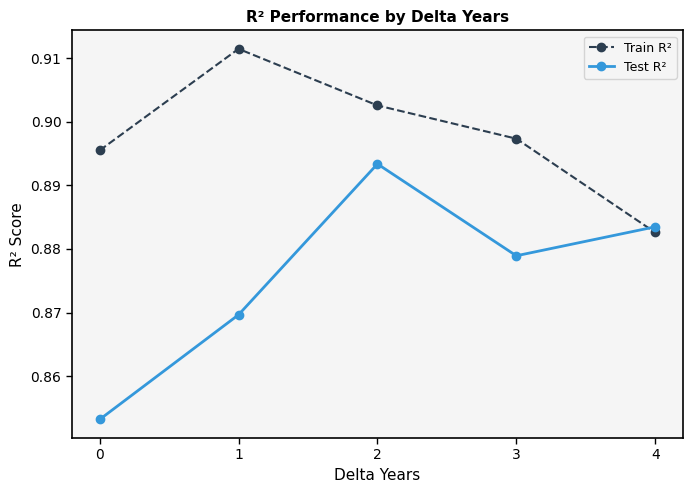

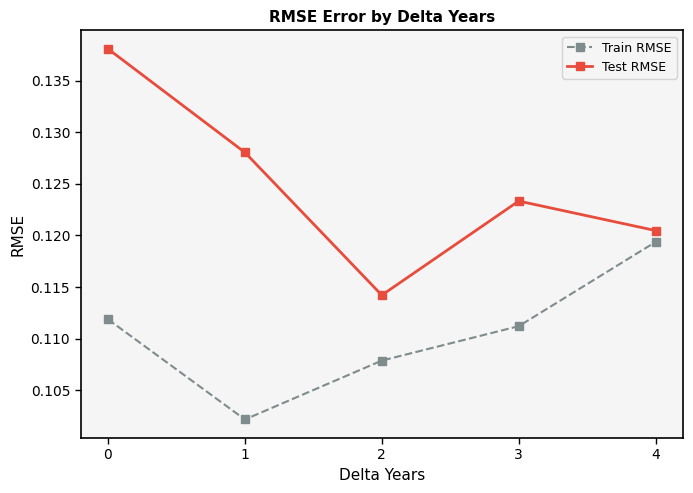

In [15]:
os.makedirs("plots_delta_vs_performance", exist_ok=True)

# Global styling
plt.rcParams.update({
    "font.size": 9,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "legend.fontsize": 9,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "axes.grid": False,
    "figure.facecolor": "white",
    "axes.facecolor": "#F5F5F5",
})

# --- Plot 1: R2 Score (Train vs Test) ---
fig1, ax1 = plt.subplots(figsize=(7, 5))

ax1.plot(res_df['delta'], res_df['train_r2'], marker='o', linestyle='--', color='#2c3e50', label='Train R²')
ax1.plot(res_df['delta'], res_df['test_r2'], marker='o', linestyle='-', color='#3498db', linewidth=2, label='Test R²')

ax1.set_title("R² Performance by Delta Years", fontweight='bold')
ax1.set_xlabel("Delta Years")
ax1.set_ylabel("R² Score")
ax1.set_xticks(delta_values)
ax1.legend()

# Spine and Tick Formatting
for side in ("top", "right", "bottom", "left"):
    ax1.spines[side].set_visible(True)
    ax1.spines[side].set_color("black")
    ax1.spines[side].set_linewidth(1.2)
ax1.tick_params(axis="both", which="major", length=4, width=1.0)

fig1.tight_layout()
fig1.savefig("plots_delta_vs_performance/r2_performance_per_delta.png", dpi=300, bbox_inches="tight")


# --- Plot 2: RMSE (Train vs Test) ---
fig2, ax2 = plt.subplots(figsize=(7, 5))

ax2.plot(res_df['delta'], res_df['train_rmse'], marker='s', linestyle='--', color='#7f8c8d', label='Train RMSE')
ax2.plot(res_df['delta'], res_df['test_rmse'], marker='s', linestyle='-', color='#e74c3c', linewidth=2, label='Test RMSE')

ax2.set_title("RMSE Error by Delta Years", fontweight='bold')
ax2.set_xlabel("Delta Years")
ax2.set_ylabel("RMSE")
ax2.set_xticks(delta_values)
ax2.legend()

# Spine and Tick Formatting
for side in ("top", "right", "bottom", "left"):
    ax2.spines[side].set_visible(True)
    ax2.spines[side].set_color("black")
    ax2.spines[side].set_linewidth(1.2)
ax2.tick_params(axis="both", which="major", length=4, width=1.0)

fig2.tight_layout()
fig2.savefig("plots_delta_vs_performance/rmse_error_per_delta.png", dpi=300, bbox_inches="tight")

plt.show()